In [1]:
import re
import unicodedata
from collections import Counter
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_theme(style="whitegrid", palette="muted")
plt.rcParams["figure.dpi"] = 120

DATA_PATH = Path.cwd().parent.parent / "data" / "processed" / "dataset_filled_subjects_new.csv"

In [20]:
# %% [load]
# Only the columns needed for keyword trends (subject_name kept for readable plot labels).
nodes = pd.read_csv(DATA_PATH, usecols=["thesis", "year", "subject_code", "subject_name"])

nodes["year"] = pd.to_numeric(nodes["year"], errors="coerce")
nodes["subject_code"] = pd.to_numeric(nodes["subject_code"], errors="coerce").astype("Int64")

# Keep rows that have a title, a year, and a subject code (the analysis needs all three).
df = nodes.dropna(subset=["thesis", "year", "subject_code"]).copy()
df["year"] = df["year"].astype(int)
df["code"] = df["subject_code"].astype(int).astype(str).str.zfill(2)

# code -> name lookup for plot labels later
code_to_name = (
    df.dropna(subset=["subject_name"])
    .groupby("code")["subject_name"]
    .agg(lambda x: x.mode()[0])
)

print(f"Total rows loaded:        {len(nodes):,}")
print(f"With title + year + code: {len(df):,}")

Total rows loaded:        338,532
With title + year + code: 234,743


In [9]:
import urllib.request
from pathlib import Path

MODEL_PATH = Path("lid.176.bin")
if not MODEL_PATH.exists():
    url = "https://dl.fbaipublicfiles.com/fasttext/supervised-models/lid.176.bin"
    print("Downloading lid.176.bin (~126 MB)...")
    urllib.request.urlretrieve(url, MODEL_PATH)
    print("Done.")

import fasttext
model = fasttext.load_model(str(MODEL_PATH))

Done.


In [34]:
# %% [language filter] fasttext, batched to dodge the NumPy 2.0 scalar-predict bug
import fasttext
from pathlib import Path

model = fasttext.load_model("lid.176.bin")

# clean titles for detection (keep natural case/accents -- lid.176 needs them)
titles = (
    df["thesis"].astype(str)
    .str.replace("\n", " ", regex=False)
    .str.strip()
    .tolist()
)

# list input -> list of label tuples; avoids the scalar predict path that
# triggers the NumPy 2.0 bug
labels, probs = model.predict(titles)   # labels: list like [('__label__en',), ...]

df["lang_ft"] = [
    lab[0].replace("__label__", "") if lab else "unknown"
    for lab in labels
]
df["is_en_ft"] = df["lang_ft"] == "en"

n_en = int(df["is_en_ft"].sum())
print(f"[fasttext] English:     {n_en:,} ({n_en / len(df):.1%})")
print(f"[fasttext] Non-English: {len(df) - n_en:,} ({1 - n_en / len(df):.1%})")

# %% [filter + cache] English-only analysis set
df_en = df[df["is_en_ft"]].copy()
print(f"Analysis set: {len(df_en):,} English titles")

# cache so the detection pass never has to rerun
out_path = Path("data/keyword_trends_english.parquet")
out_path.parent.mkdir(parents=True, exist_ok=True)
# pickle: preserves dtypes 
df_en.to_pickle("data/keyword_trends_english.pkl")
print("Saved to data/keyword_trends_english.pkl")

[fasttext] English:     208,150 (88.7%)
[fasttext] Non-English: 26,593 (11.3%)
Analysis set: 208,150 English titles
Saved to data/keyword_trends_english.pkl


In [35]:
df_en = pd.read_pickle("data/keyword_trends_english.pkl")

Peak year:        2013 (5,826 titles)
START_YEAR:       1948
TREND_END:        2023
Usable titles:    200,405 (96.3% of English set)


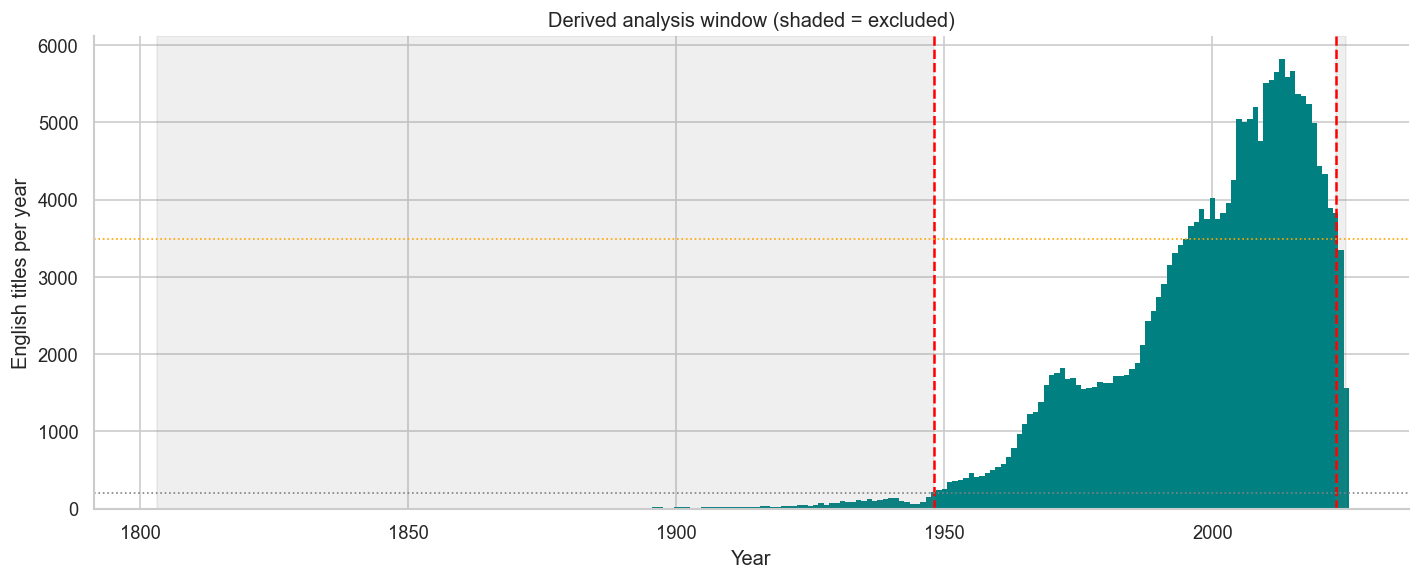

In [36]:
# %% [dynamic year window] derive START_YEAR / TREND_END from the English data
# Rules, not magic numbers:
#   START_YEAR = first year with enough titles for a stable yearly share
#   TREND_END  = last year before the data-entry lag drop-off

MIN_TITLES_PER_YEAR = 200    # floor for a usable year
LAG_DROP_FRAC       = 0.60   # cut tail once counts fall below this fraction of peak

per_year = (
    df_en.assign(year=lambda d: d["year"].astype(int))
    .query("1800 <= year <= 2025")
    .groupby("year")
    .size()
    .sort_index()
)

# START_YEAR: first year at or above the floor
START_YEAR = int(per_year[per_year >= MIN_TITLES_PER_YEAR].index.min())

# TREND_END: walk forward from the peak, keep years still above the lag threshold
peak_year = int(per_year.idxmax())
peak_val  = int(per_year.max())
tail = per_year[per_year.index >= peak_year]
TREND_END = int(tail[tail >= LAG_DROP_FRAC * peak_val].index.max())

usable = per_year[(per_year.index >= START_YEAR) & (per_year.index <= TREND_END)]
print(f"Peak year:        {peak_year} ({peak_val:,} titles)")
print(f"START_YEAR:       {START_YEAR}")
print(f"TREND_END:        {TREND_END}")
print(f"Usable titles:    {usable.sum():,} ({usable.sum() / len(df_en):.1%} of English set)")

# %% [plot] derived window on the full curve
fig, ax = plt.subplots(figsize=(12, 5))
ax.bar(per_year.index, per_year.values, color="teal", edgecolor="none", width=1.0)
ax.axvline(START_YEAR, color="red", linestyle="--", linewidth=1.5)
ax.axvline(TREND_END, color="red", linestyle="--", linewidth=1.5)
ax.axhline(MIN_TITLES_PER_YEAR, color="gray", linestyle=":", linewidth=1)
ax.axhline(LAG_DROP_FRAC * peak_val, color="orange", linestyle=":", linewidth=1)
ax.axvspan(per_year.index.min(), START_YEAR, color="gray", alpha=0.12)
ax.axvspan(TREND_END, per_year.index.max(), color="gray", alpha=0.12)
ax.set_xlabel("Year")
ax.set_ylabel("English titles per year")
ax.set_title("Derived analysis window (shaded = excluded)")
sns.despine(ax=ax)
plt.tight_layout()
plt.show()

NameError: name 'strip_accents' is not defined

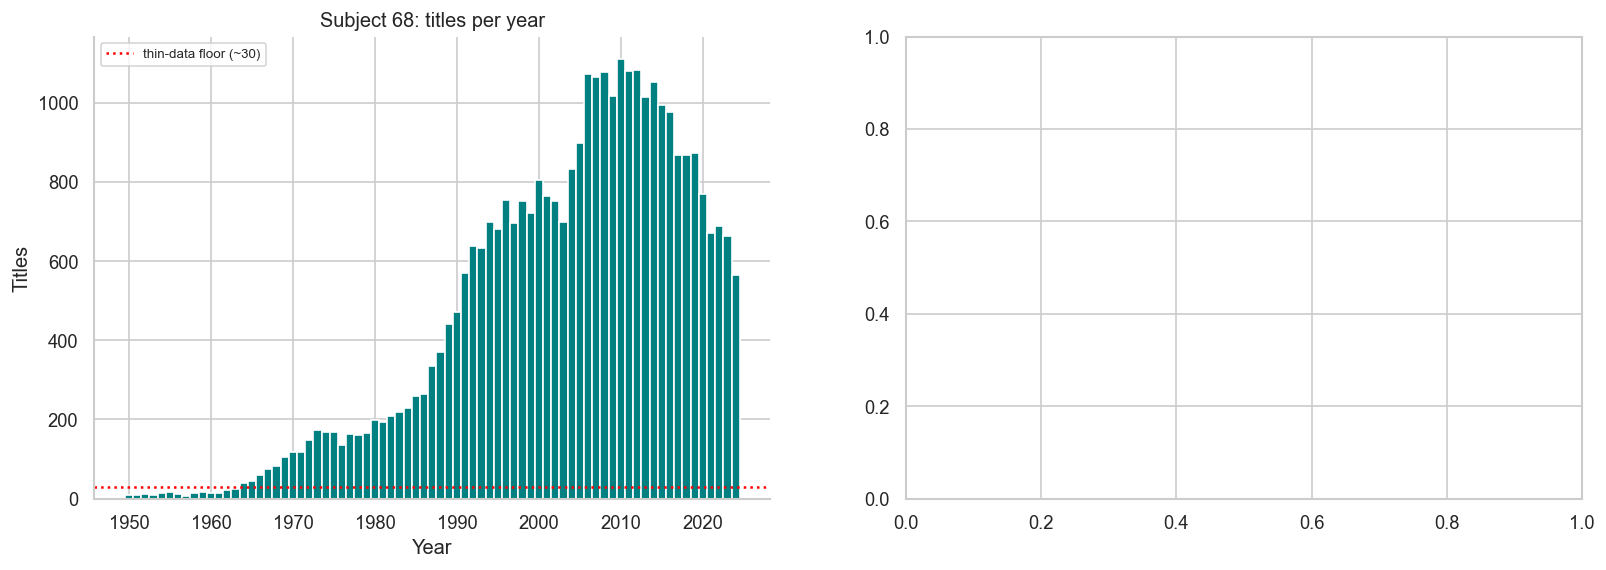

In [37]:
# %% per-subject usable window: volume + word-share stability
SUBJECT = "68"   # change per subject

sub = (
    df_en[df_en["code"] == SUBJECT]
    .assign(year=lambda d: d["year"].astype(int))
    .query("1950 <= year <= 2024")
)

# titles per year within this subject
sub_per_year = sub.groupby("year").size()

fig, axes = plt.subplots(1, 2, figsize=(16, 5))

# left: volume within the subject
axes[0].bar(sub_per_year.index, sub_per_year.values, color="teal", width=1.0)
axes[0].axhline(30, color="red", linestyle=":", label="thin-data floor (~30)")
axes[0].set_title(f"Subject {SUBJECT}: titles per year")
axes[0].set_xlabel("Year"); axes[0].set_ylabel("Titles")
axes[0].legend(fontsize=8); sns.despine(ax=axes[0])

# right: a few top words' share within the subject over time
from collections import Counter
def toks(t):  # uses your tokens() if defined; fallback here
    return [w for w in re.findall(r"[a-z]{4,}", strip_accents(t.lower()))]

words_by_year, total_by_year = {}, {}
for y, t in zip(sub["year"], sub["thesis"]):
    ws = toks(t)
    words_by_year.setdefault(y, Counter()).update(ws)
    total_by_year[y] = total_by_year.get(y, 0) + len(ws)

overall = Counter()
for c in words_by_year.values():
    overall.update(c)
top_words = [w for w, _ in overall.most_common(60) if len(w) > 4][:5]

years = sorted(words_by_year)
for w in top_words:
    sh = [words_by_year[y].get(w, 0) / max(total_by_year[y], 1) for y in years]
    axes[1].plot(years, pd.Series(sh, index=years).rolling(3, center=True).mean(),
                 linewidth=2, label=w)
axes[1].set_title(f"Subject {SUBJECT}: top-word shares (3-yr smoothed)")
axes[1].set_xlabel("Year"); axes[1].set_ylabel("Share of subject's title words")
axes[1].legend(fontsize=8); sns.despine(ax=axes[1])

plt.tight_layout()
plt.show()

print(f"Subject {SUBJECT}: last year with >=30 titles = "
      f"{int(sub_per_year[sub_per_year >= 30].index.max())}")

In [56]:
# tunable parameters
START_YEAR   = 1950   # before this, titles are too sparse to trust shares
TREND_END    = 2018  # cut the post-2018 data-entry lag tail
MIN_TOTAL    = 300    # min total occurrences for a word to be considered
RECENT       = 10     # length of the recent window for the slope (years)
MIN_RECENT_N = 50     # min occurrences inside the recent window to trust the slope
MIN_WORD_LEN = 4      # token regex length floor; raising cuts more short filler
TOP_K        = 15     # how many rising words to show

In [61]:
# %% [tokenizer]
# strip accents BEFORE tokenizing or remove languages other than English
token_re = re.compile(r"[a-z]{4,}")

STOP = {
    "the", "and", "for", "with", "from", "study", "analysis", "theory",
    "problem", "problems", "using", "based", "model", "models", "method",
    "methods", "approach", "approaches", "general", "application",
    "applications", "system", "systems", "new", "some", "via", "toward",
    "towards", "novel", "properties", "results",
}

def strip_accents(s):
    return "".join(c for c in unicodedata.normalize("NFD", s)
                   if unicodedata.category(c) != "Mn")

def tokens(title):
    title = strip_accents(title.lower())
    return [w for w in token_re.findall(title) if w not in STOP]


In [62]:
# %% [per-year counts for one subject]
def build_year_counts(subject_code):
    """Return year_word (year -> Counter) and year_total (year -> n words)."""
    sub = df[df["code"] == subject_code]
    year_word, year_total = {}, {}
    for year, title in zip(sub["year"], sub["thesis"]):
        toks = tokens(title)
        year_word.setdefault(year, Counter()).update(toks)
        year_total[year] = year_total.get(year, 0) + len(toks)
    return year_word, year_total

SUBJECT = "24"  # start with CS; change to "11" for number theory, etc.
year_word, year_total = build_year_counts(SUBJECT)

# overall counts to drop rare words
overall = Counter()
for c in year_word.values():
    overall.update(c)
common_words = {w for w, n in overall.items() if n >= MIN_TOTAL}
print(f"Subject {SUBJECT}: {len(common_words)} words above MIN_TOTAL")

# %% [rising-word detection via slope]
RECENT = 10
recent_years = list(range(TREND_END - RECENT + 1, TREND_END + 1))

def share_series(word, years):
    return np.array([
        year_word.get(y, Counter()).get(word, 0) / year_total[y]
        for y in years if year_total.get(y, 0) > 0
    ])

def slope_per_decade(word, years):
    ys = share_series(word, years)
    if len(ys) < 5:
        return np.nan
    return np.polyfit(range(len(ys)), ys, 1)[0] * 10 * 100  # %-points per decade

rows = [{"word": w, "recent_slope": slope_per_decade(w, recent_years),
         "total": overall[w]} for w in common_words]
rising = pd.DataFrame(rows).dropna()
rising = rising[rising["recent_slope"] > 0].nlargest(15, "recent_slope")

print(rising.round(3).to_string(index=False))


Subject 24: 0 words above MIN_TOTAL


KeyError: 'recent_slope'

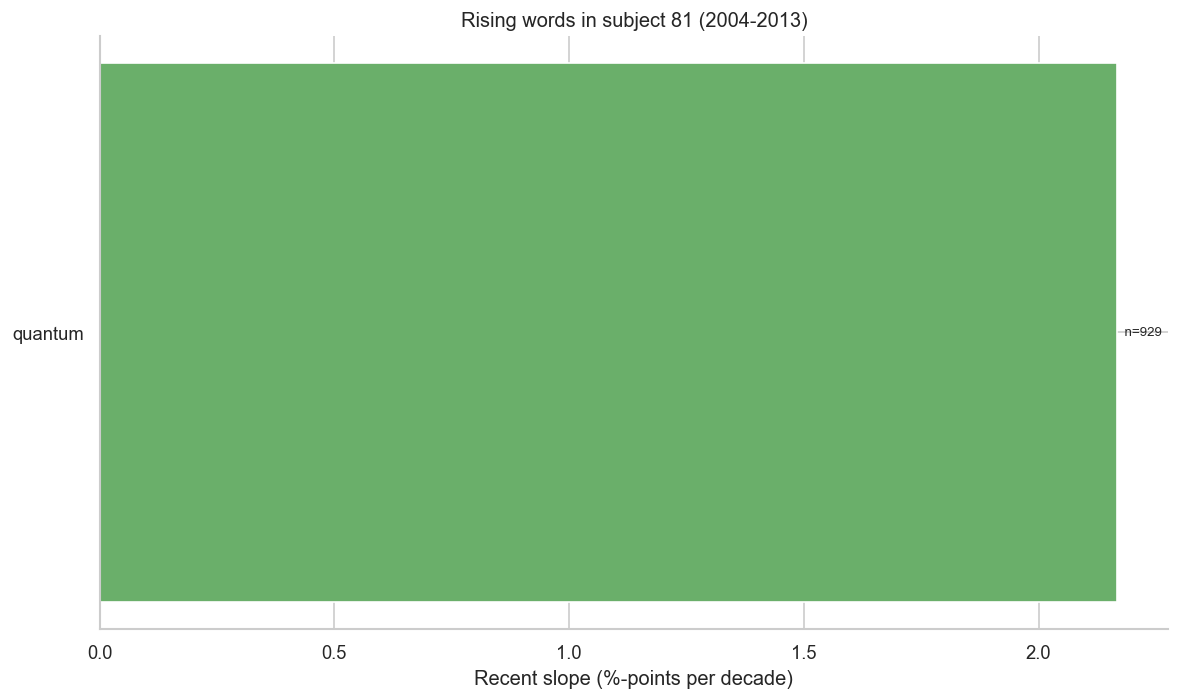

In [ ]:
# %% [plot rising words]
fig, ax = plt.subplots(figsize=(10, 6))
d = rising.sort_values("recent_slope")
ax.barh(d["word"], d["recent_slope"], color="#6aaf6a", edgecolor="white")
for i, (_, r) in enumerate(d.iterrows()):
    ax.text(r["recent_slope"], i, f"  n={int(r['total']):,}", va="center", fontsize=8)
ax.set_xlabel("Recent slope (%-points per decade)")
ax.set_title(f"Rising words in subject {SUBJECT} ({recent_years[0]}-{TREND_END})")
sns.despine(ax=ax)
plt.tight_layout()
plt.show()